<a href="https://colab.research.google.com/github/Shojaiaa/Prediction-of-Product-Sales/blob/main/project_1_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Pandas and load the dataset
import pandas as pd
sales_predictions = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week03/sales_predictions_2023.csv'
df = pd.read_csv(sales_predictions)
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [ ]:
# Preview the first five rows of the dataset
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
# How many rows and columns?
df.shape

(8523, 12)

In [ ]:
# What are the datatypes of each variable?
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [ ]:
# Are there duplicates? If so, drop any duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Identify missing values
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
# Address the missing values by using a placeholder value
df['Item_Weight'] = df['Item_Weight'].fillna(-1)
df['Outlet_Size'] = df['Outlet_Size'].fillna('MISSING')

In [ ]:
# Confirm that there are no missing values after addressing them
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
# Find any inconsistent categories of data
string_columns = df.select_dtypes(include= ['object']).columns
for col in string_columns:
    print(col)
    print(df[col].value_counts())
    print('\n')


Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT0

In [ ]:
# Fix inconsistent values in Item_Fat_Content
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular',
})

In [ ]:
# Check the values after fixing inconsistencies
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
# Fix inconsistent data
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'reg': 'Regular',
    'low fat': 'Low Fat'
})
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
# For any numerical columns, obtain the summary statistics of each (min, max, mean)
df.select_dtypes(include=['number']).agg(['min', 'max', 'mean'])

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,-1.000000,0.000000,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
mean,10.478936,0.066132,140.992782,1997.831867,2181.288914


In [ ]:
# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


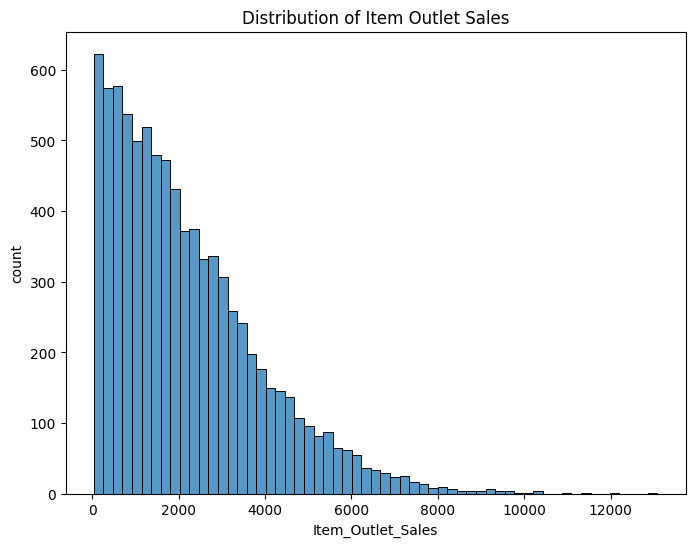

In [ ]:
# Histogram to view the distribution of Item Outlet Sales
plt.figure(figsize=(8, 6))

sns.histplot(data=df, x= 'Item_Outlet_Sales', bins= 'auto')
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item_Outlet_Sales')
plt.ylabel('count')

plt.show()

# The graph shows that the sales outlet brings in a large number of products that generate medium to low sales and a very small number of high sales.

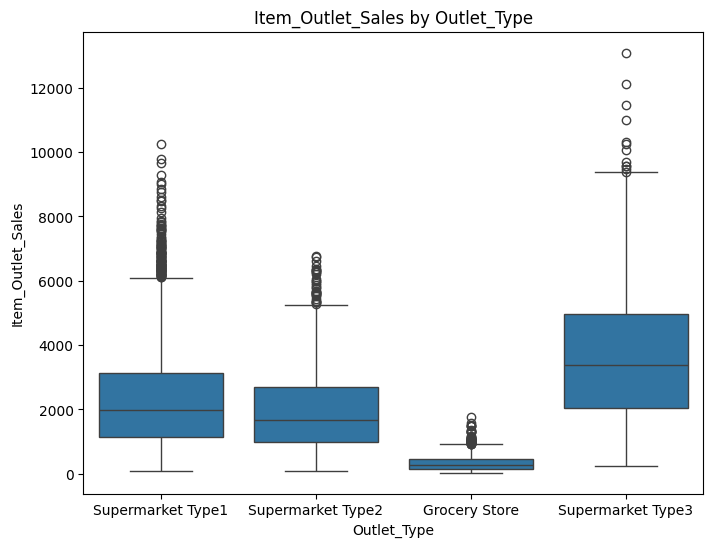

In [ ]:
# Boxplot: Item Outlet Sales by Outlet Type
plt.figure(figsize=(8, 6))

sns.boxplot(data=df,x='Outlet_Type', y='Item_Outlet_Sales')
plt.title('Item_Outlet_Sales by Outlet_Type')
plt.xlabel('Outlet_Type')
plt.ylabel('Item_Outlet_Sales')

plt.show()

# Supermarket Type3 shows the highest median sales compared to other outlet types, suggesting that outlet type is an important factor in sales performance.

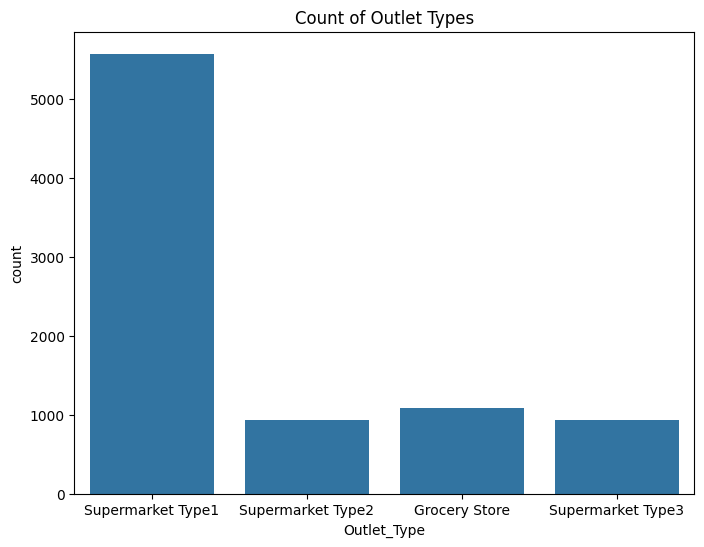

In [ ]:
# Countplot: Frequency of Outlet Types
plt.figure(figsize=(8, 6))

sns.countplot(data=df,x='Outlet_Type')
plt.title('Count of Outlet Types')
plt.xlabel('Outlet_Type')
plt.ylabel('count')

plt.show()

# Although Supermarket Type1 appears most frequently in the dataset, the previous boxplot showed that Supermarket Type3 has higher sales, suggesting that outlet frequency does not necessarily reflect sales performance.

In [ ]:
# Get correlations
corr= df.corr(numeric_only= True)
corr.round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.00,-0.08,0.02,0.54,-0.06
Item_Visibility,-0.08,1.00,-0.00,-0.07,-0.13
Item_MRP,0.02,-0.00,1.00,0.01,0.57
Outlet_Establishment_Year,0.54,-0.07,0.01,1.00,-0.05
Item_Outlet_Sales,-0.06,-0.13,0.57,-0.05,1.00


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

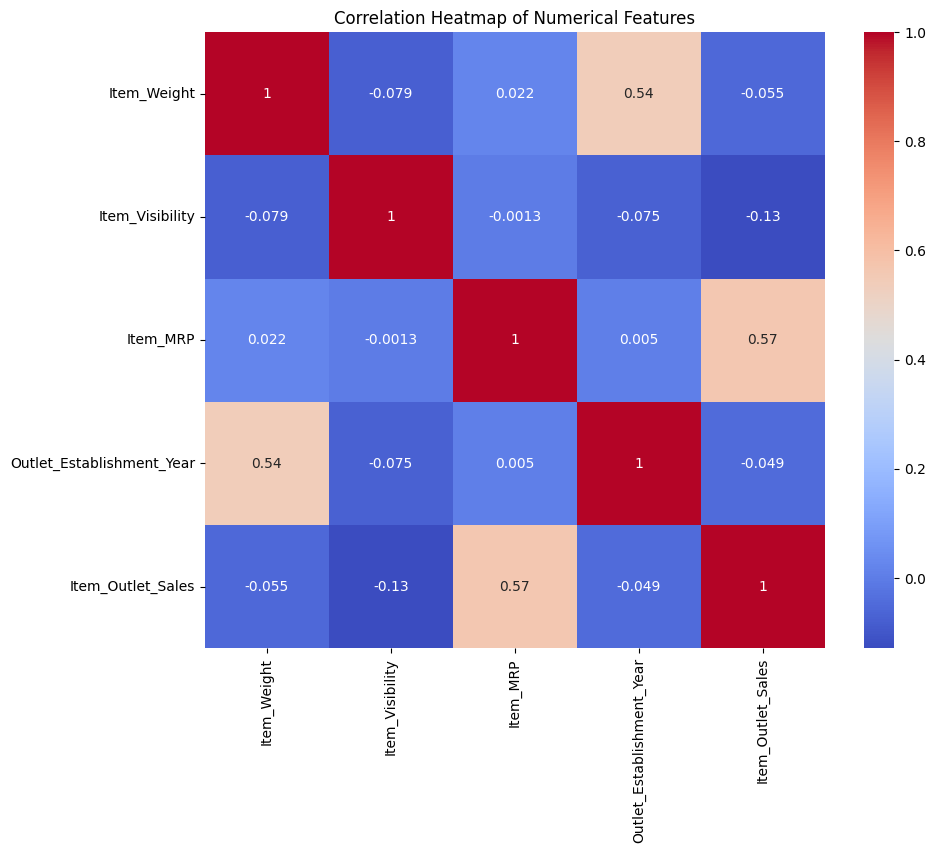

In [ ]:
# Make heatmap of correlations
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, cmap = 'coolwarm', annot = True, ax=ax);
plt.title('Correlation Heatmap of Numerical Features')

# The heatmap shows that Item_MRP has the strongest positive correlation with Item_Outlet_Sales. Combined with the previous boxplot, this suggests that both product pricing and outlet type may be important factors in sales performance.

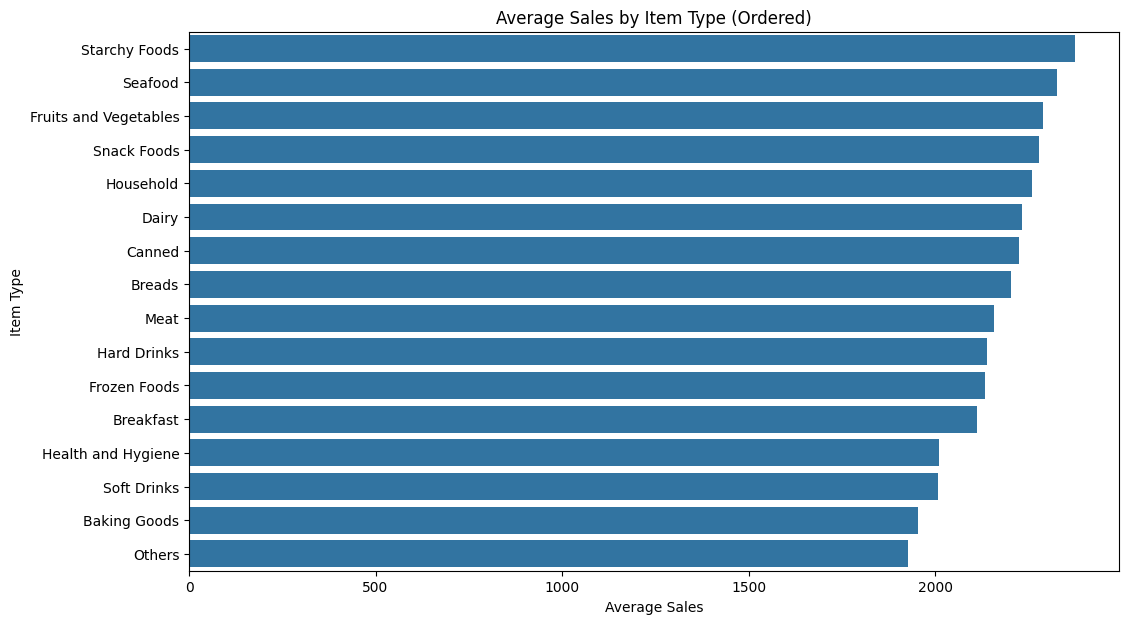

In [ ]:
plt.figure(figsize=(12, 7))

# Product ranking based on highest average sales
ordered_items = df.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).index

# Sales drawing
sns.barplot(data=df, x='Item_Outlet_Sales', y='Item_Type', order=ordered_items, errorbar=None)

plt.title('Average Sales by Item Type (Ordered)')
plt.xlabel('Average Sales')
plt.ylabel('Item Type')
plt.show()

# The graph shows the average sales for products from highest to lowest.

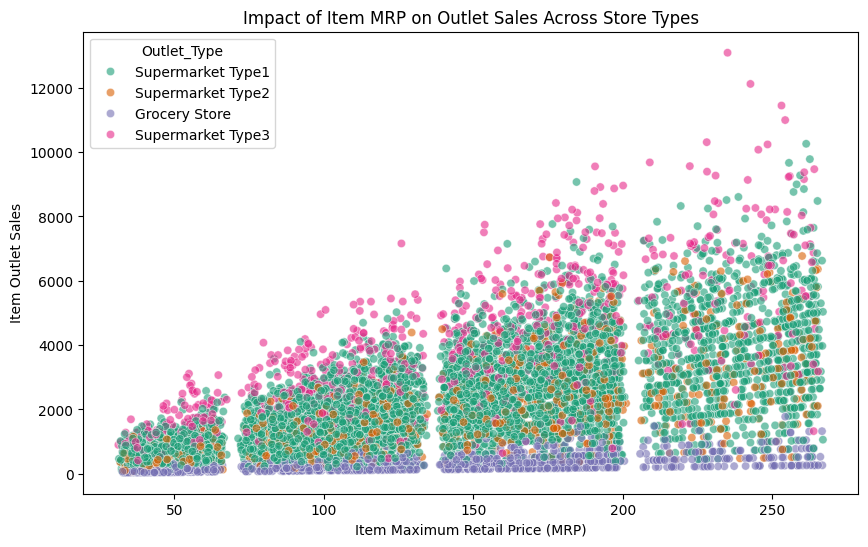

In [ ]:
plt.figure(figsize=(10, 6))

# Charting the relationship between price and sales according to store type
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', hue='Outlet_Type', alpha=0.6, palette='Dark2')

plt.title('Impact of Item MRP on Outlet Sales Across Store Types')
plt.xlabel('Item Maximum Retail Price (MRP)')
plt.ylabel('Item Outlet Sales')

plt.show()

# The chart shows that higher item prices are usually linked with higher sales. Grocery Stores seem to have the lowest sales, while Supermarket Type3 performs better than the other store types.